 In order to first evaluate the bhdsgan I will use the following procedure:
 1. Sample from a truncated normal distribution with high variance --> gan should perform poorly
 2. Train gan on sampled data
 3. Generate new data and estimate density
 4. Compare actual and estimated density
 5. Sample from a truncated normal distribution with low variance --> gan should perform quite well
 6.Train gan on sampled data
 7. Generate new data and estimate density
 8. Compare actual and estimated density

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from torch import nn
from bhsgan import DiscriminatorBhsSim, GeneratorBhsSim,GeneratorBhsSimNormal
from dataset import SampleDataset
from ipmbhsgan import DiscriminatorIpmSim, GeneratorIpmSim
from trainer import (Trainer, TrainingParams, get_dis_loss_bhs,
                     get_dis_loss_ipm, get_dis_loss_wasserstein,
                     get_gen_loss_bhs, get_gen_loss_ipm,
                     get_gen_loss_wasserstein,get_dis_loss_kl, get_gen_loss_kl, get_dis_loss_rkl, get_gen_loss_rkl,
                     get_dis_loss_gan, get_gen_loss_gan, get_dis_loss_p, get_gen_loss_p)
from utils import get_device, get_noise, init_weights, plot_tensor_images, plot_losses, BhsActivation, save_models_state_dict, load_model_state_dict, RevKlActivation, GanGanActivation
from wgan import DiscriminatorWassersteinSim, GeneratorWassersteinSim, GeneratorWassersteinSimNormal
import random
from scipy.stats import lognorm

torch.set_default_dtype(torch.float64)
torch.manual_seed(96)
random.seed(96)

## sample from beta distribution

In [3]:
# sample from beta distributions
mean_1_low = 0
sd_1_low = 0.5
mean_2_low = 5
sd_2_low = 1
mean_1_high = 0
sd_1_high = 2
mean_2_high = 5
sd_2_high = 2


In [4]:
# beta_sample_high = np.random.beta(a_high, b_high, 10000)
normal_sample_1_high = np.random.choice(np.random.lognormal(mean_1_high, sd_1_high, 10000), 5000)
normal_sample_2_high = np.random.choice(np.random.lognormal(mean_2_high, sd_2_high, 10000), 5000)
sample_high = np.concatenate([normal_sample_1_high, normal_sample_2_high])
beta_sample_high = np.reshape(sample_high, (5000, 2))

<Axes: ylabel='Count'>

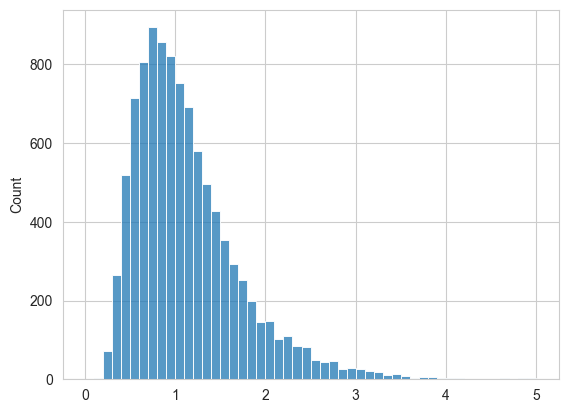

In [5]:
#normal_sample_1_low = np.random.lognormal(mean_1_low, sd_1_low, 10000)
normal_sample_1_low = lognorm.rvs(s=0.5, loc=0, scale=1, size=10000)
normal_sample_1_high = np.random.lognormal(mean_2_high, sd_2_high, 10000)
#normal_sample_2_low = np.random.choice(np.random.normal(mean_2_low, sd_2_low, 10000), 5000)
#sample_low = np.concatenate([normal_sample_1_low, normal_sample_2_low])
beta_sample_high = np.reshape(normal_sample_1_high, (10000, 1))
beta_sample_low = np.reshape(normal_sample_1_low, (10000, 1))
sns.set_style('whitegrid')
sns.histplot(beta_sample_low.ravel(), bins=50, binrange=[0,5])

In [6]:
training_set_high = SampleDataset(beta_sample_high)
training_set_low = SampleDataset(beta_sample_low)

In [7]:
test_noise = get_noise(10000, 1)
beta_sample_low

array([[0.97615188],
       [1.37581132],
       [1.30596014],
       ...,
       [0.62395207],
       [2.05661116],
       [0.84786267]])

## Train BHS GAN

In [53]:
# old seed 97
torch.manual_seed(14)
random.seed(14)
training_params = TrainingParams(lr_dis=0.00004,
                                 lr_gen=0.00004,
                                 num_epochs=40,
                                 num_dis_updates=3,
                                 num_gen_updates=2,
                                 beta_1=0.5,
                                 beta_2=0.999,
                                 weight_decay=0,
                                 batch_size=64, 
                                 lr_annealing=False)
 
# get device to train on
device = "cpu"

In [54]:
# Create the dataloaders
dataloader_high = torch.utils.data.DataLoader(training_set_high, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
dataloader_low = torch.utils.data.DataLoader(training_set_low, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)

In [55]:
# Create the dataloaders
dataloader_high = torch.utils.data.DataLoader(training_set_high, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
dataloader_low = torch.utils.data.DataLoader(training_set_low, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
# initialize nets
final_activation = BhsActivation
generator_high = GeneratorBhsSimNormal()
discriminator_high = DiscriminatorBhsSim(final_activation)
generator_low = GeneratorBhsSimNormal()
discriminator_low = DiscriminatorBhsSim(final_activation)

In [56]:
# init Trainer
trainer_high = Trainer(training_params, generator_high, discriminator_high)
trainer_low = Trainer(training_params, generator_low, discriminator_low)

### Train on low variance samples

In [57]:
# training loop
trained_bhs_low = trainer_low.train_gan(dataloader_low, get_dis_loss_bhs, get_gen_loss_bhs, True, print_intermediate=False)

Epoch 1 start training...
Epoch: 1/40 Total Steps:157poch_Run_Time: 3.388312	Loss_C : -0.066689	Loss_G : -0.132642	
Total_Time : 3.686386
Loss_C : -0.066689
Loss_G : -0.132642
Loss_C_Mean : 0.046594
Loss_G_Mean : -0.208426

----------------------------------------------

Epoch 2 start training...
Epoch: 2/40 Total Steps:314poch_Run_Time: 3.436133	Loss_C : -0.006444	Loss_G : -0.010320	
Total_Time : 3.749867
Loss_C : -0.006444
Loss_G : -0.010320
Loss_C_Mean : 0.034867
Loss_G_Mean : -0.066307

----------------------------------------------

Epoch 3 start training...
Epoch: 3/40 Total Steps:471poch_Run_Time: 3.460046	Loss_C : 0.024034	Loss_G : -0.012310		
Total_Time : 3.780771
Loss_C : 0.024034
Loss_G : -0.012310
Loss_C_Mean : -0.013027
Loss_G_Mean : -0.010147

----------------------------------------------

Epoch 4 start training...
Epoch: 4/40 Total Steps:628poch_Run_Time: 3.340394	Loss_C : -0.008268	Loss_G : -0.006507	
Total_Time : 3.638519
Loss_C : -0.008268
Loss_G : -0.006507
Loss_C_M

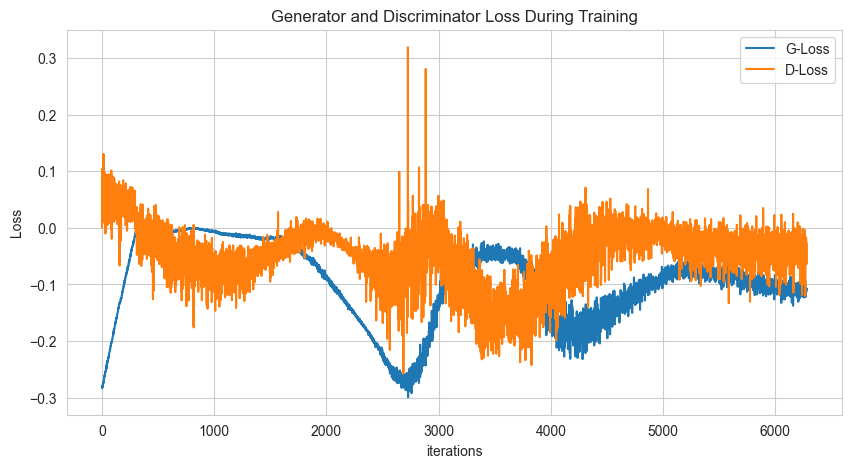

In [58]:
plot_losses(trained_bhs_low.generator_losses, trained_bhs_low.discriminator_losses)

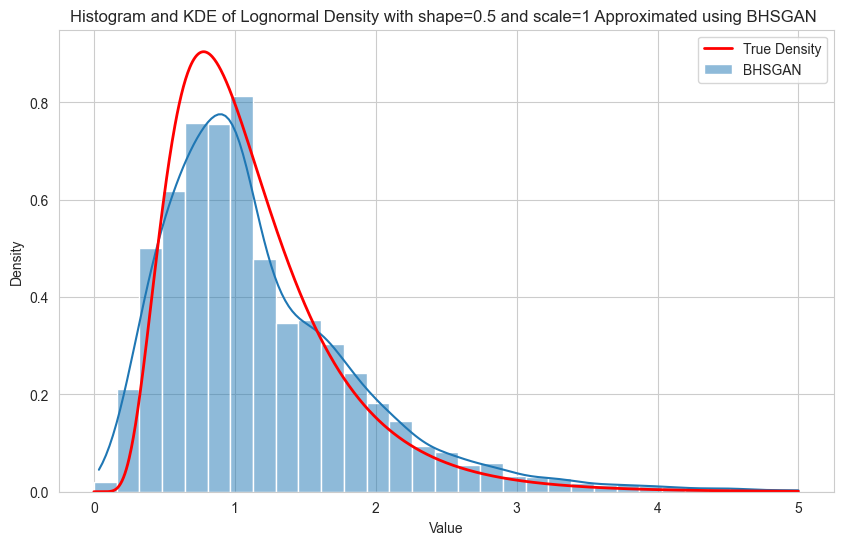

In [69]:
random.seed(10)
test_noise = get_noise(10000, 1)
generated_data_low = trained_bhs_low.generator(test_noise).detach().numpy()
generated_data_low

plt.figure(figsize=(10, 6))

# Plot histogram
sns.histplot(generated_data_low.ravel(),
             kde=True,
             stat='density',
             bins=31, binrange=[0,5],
             label='BHSGAN',
             kde_kws = {'clip':[0,5],
                       'bw_adjust':1.2})
#sns.kdeplot(generated_data_low.ravel(),bw_adjust=1,label='KDE BHS', clip=[0,5])
# Calculate true lognormal density
x = np.linspace(0, 5, 1000)
pdf = lognorm.pdf(x,s=0.5, scale= 1,loc=0)


# Plot true density
plt.plot(x, pdf, 'r-', lw=2, label='True Density')

plt.title('Histogram and KDE of Lognormal Density with shape=0.5 and scale=1 Approximated using BHSGAN ')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.savefig('Pictures/BHSGAN_KDE.svg')

plt.show()

In [65]:
loc_vec,scale_vec,shape_vec= [],[],[]

for i in range(5000):
    test_noise = get_noise(10000, 1)
    generated_data_low = trained_bhs_low.generator(test_noise).detach().numpy()
    generated_data_low
    
    shape, location, scale = lognorm.fit(generated_data_low.ravel())
    loc_vec.append(location),scale_vec.append(scale),shape_vec.append(shape)

print(np.mean(shape_vec),np.std(shape_vec),np.mean(scale_vec),np.std(scale_vec))


0.536988839861036 0.008417292658804514 1.0955665528677876 0.016152120777782452


## Wasserstein GAN 

### High Variance

In [16]:
dataloader_wasserstein_high = torch.utils.data.DataLoader(training_set_high, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
generator_wasserstein_high = GeneratorWassersteinSimNormal()
discriminator_wasserstein_high = DiscriminatorWassersteinSim()
trainer_wgan_high = Trainer(training_params, generator_wasserstein_high, discriminator_wasserstein_high)

In [17]:
# training loop
trained_wgan_high = trainer_wgan_high.train_gan(dataloader_wasserstein_high, get_dis_loss_wasserstein, get_gen_loss_wasserstein, True, print_intermediate=False)

Epoch 1 start training...
Epoch: 1/40 Total Steps:157poch_Run_Time: 3.086130	Loss_C : -61.156973	Loss_G : -0.502490		
Total_Time : 3.362235
Loss_C : -61.156973
Loss_G : -0.502490
Loss_C_Mean : -222.858678
Loss_G_Mean : -0.449190

----------------------------------------------

Epoch 2 start training...
Epoch: 2/40 Total Steps:314poch_Run_Time: 2.993627	Loss_C : -426.754712	Loss_G : -0.677577		
Total_Time : 3.265679
Loss_C : -426.754712
Loss_G : -0.677577
Loss_C_Mean : -334.359756
Loss_G_Mean : -0.573507

----------------------------------------------

Epoch 3 start training...
Epoch: 3/40 Total Steps:471poch_Run_Time: 3.097547	Loss_C : -165.930535	Loss_G : -0.902818		
Total_Time : 3.369601
Loss_C : -165.930535
Loss_G : -0.902818
Loss_C_Mean : -443.950748
Loss_G_Mean : -0.758019

----------------------------------------------

Epoch 4 start training...
Epoch: 4/40 Total Steps:628poch_Run_Time: 3.004946	Loss_C : -856.632375	Loss_G : -1.204478		
Total_Time : 3.271774
Loss_C : -856.632375


In [18]:
generated_data_wasserstein_high = trained_wgan_high.generator(test_noise)
generated_sample_wasserstein_high = torch.reshape(generated_data_wasserstein_high, (1, 20000)).detach().numpy().ravel()
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample_wasserstein_high, bins=100)

RuntimeError: shape '[1, 20000]' is invalid for input of size 10000

### Low Variance

In [ ]:
dataloader_wasserstein_low = torch.utils.data.DataLoader(training_set_low, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
generator_wasserstein_low = GeneratorWassersteinSimNormal()
discriminator_wasserstein_low = DiscriminatorWassersteinSim()
trainer_wgan_low = Trainer(training_params, generator_wasserstein_low, discriminator_wasserstein_low)

In [ ]:
# training loop
trained_wgan_low = trainer_wgan_low.train_gan(dataloader_wasserstein_low, get_dis_loss_wasserstein, get_gen_loss_wasserstein, True, print_intermediate=False)

In [ ]:
generated_data_wasserstein_low = trained_wgan_low.generator(test_noise)
generated_sample_wasserstein_low = generated_data_wasserstein_low.detach().numpy().ravel()
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample_wasserstein_low, bins=50, binrange=[0,5])

In [ ]:
plt.figure(figsize=(10, 6))

# Plot histogram
sns.histplot(generated_sample_wasserstein_low,
             kde=True,
             stat='density',
             bins=40, binrange=[0,5],
             label='WGAN',
             kde_kws = {'clip':[0,5]})

x = np.linspace(0, 5, 1000)
pdf = lognorm.pdf(x,s=0.5, scale= 1)


# Plot true density
plt.plot(x, pdf, 'r-', lw=2, label='True Density')

plt.title('Histogram and KDE of Lognormal Density with shape=0.5 and scale=1 Approximated using WGAN ')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.savefig('Pictures/WGAN_KDE.png')
plt.show()



In [ ]:
loc_vec,scale_vec,shape_vec= [],[],[]

for i in range(500):
    test_noise = get_noise(10000, 1)
    generated_data_low = trained_wgan_low.generator(test_noise).detach().numpy().ravel()
    generated_data_low
    
    shape, location, scale = lognorm.fit(generated_data_low.ravel())
    loc_vec.append(location),scale_vec.append(scale),shape_vec.append(shape)

print(np.mean(scale_vec),np.std(scale_vec),np.mean(shape_vec),np.std(shape_vec))

## GAN GAN 

In [ ]:
# Create the dataloaders
dataloader_high = torch.utils.data.DataLoader(training_set_high, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
dataloader_low = torch.utils.data.DataLoader(training_set_low, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
# initialize nets
final_activation = nn.Sigmoid
generator_gan_high = GeneratorBhsSimNormal()
discriminator_gan_high = DiscriminatorBhsSim(final_activation)
generator_gan_low = GeneratorBhsSimNormal()
discriminator_gan_low = DiscriminatorBhsSim(final_activation)

In [ ]:
trainer_gan_high = Trainer(training_params, generator_gan_high, discriminator_gan_high)

In [ ]:
# training loop
trained_gan_high = trainer_gan_high.train_gan(dataloader_high, get_dis_loss_gan, get_gen_loss_gan, False, print_intermediate=False)

In [ ]:
generated_data_gan_high = trained_gan_high.generator(test_noise)
generated_sample_gan_high = torch.reshape(generated_data_gan_high, (1, 20000)).detach().numpy().ravel()
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample_gan_high, bins=50)

### Low Variance

In [ ]:
trainer_gan_low = Trainer(training_params, generator_gan_low, discriminator_gan_low)

In [ ]:
# training loop
trained_gan_low = trainer_gan_low.train_gan(dataloader_low, get_dis_loss_gan, get_gen_loss_gan, False, print_intermediate=False)

In [ ]:
generated_data_gan_low = trained_gan_low.generator(test_noise)
generated_sample_gan_low = generated_data_gan_low.detach().numpy().ravel()
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample_gan_low, bins=50, binrange=[0,5])

In [ ]:
plt.figure(figsize=(10, 6))

# Plot histogram
sns.histplot(generated_sample_gan_low,
             kde=True,
             stat='density',
             bins=40, binrange=[0,5],
             label='GAN',
             kde_kws = {'clip':[0,5]})

x = np.linspace(0, 5, 1000)
pdf = lognorm.pdf(x,s=0.5, scale= 1)


# Plot true density
plt.plot(x, pdf, 'r-', lw=2, label='True Density')

plt.title('Histogram and KDE of Lognormal Density with shape=0.5 and scale=1 Approximated using GAN ')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.savefig('Pictures/GAN_KDE.png')
plt.show()

In [ ]:
loc_vec,scale_vec,shape_vec= [],[],[]

for i in range(500):
    test_noise = get_noise(10000, 1)
    generated_data_low = trained_gan_low.generator(test_noise).detach().numpy().ravel()
    generated_data_low
    
    shape, location, scale = lognorm.fit(generated_data_low.ravel())
    loc_vec.append(location),scale_vec.append(scale),shape_vec.append(shape)

print(np.mean(scale_vec),np.std(scale_vec),np.mean(shape_vec),np.std(shape_vec))

## Pearson GAN

In [ ]:
# Create the dataloaders
dataloader_high = torch.utils.data.DataLoader(training_set_high, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
dataloader_low = torch.utils.data.DataLoader(training_set_low, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
# initialize nets
final_activation = nn.Identity
generator_pearson_high = GeneratorBhsSimNormal()
discriminator_pearson_high = DiscriminatorBhsSim(final_activation)
generator_pearson_low = GeneratorBhsSimNormal()
discriminator_pearson_low = DiscriminatorBhsSim(final_activation)

### Low Variance

In [ ]:
torch.manual_seed(11)
random.seed(11)
trainer_pearson_low = Trainer(training_params, generator_pearson_low, discriminator_pearson_low)

In [ ]:
# training loop
trained_pearson_low = trainer_pearson_low.train_gan(dataloader_low, get_dis_loss_p, get_gen_loss_p, True, print_intermediate=False)

In [ ]:
test_noise = get_noise(10000, 1)
generated_data_pearson_low = trained_pearson_low.generator(test_noise)
generated_sample_pearson_low = generated_data_pearson_low.detach().numpy().ravel()
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample_pearson_low, bins=50, binrange=[0,5])

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(generated_sample_pearson_low,
             kde=True,
             stat='density',
             bins=40, binrange=[0,5],
             label='Pearson GAN',
             kde_kws = {'clip':[0,5]})

x = np.linspace(0, 5, 1000)
pdf = lognorm.pdf(x,s=0.5, scale= 1)


# Plot true density
plt.plot(x, pdf, 'r-', lw=2, label='True Density')

plt.title('Histogram and KDE of Lognormal Density with shape=0.5 and scale=1 Approximated using Pearson GAN ')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.savefig('Pictures/Pearson_KDE.png')
plt.show()

In [ ]:
loc_vec,scale_vec,shape_vec= [],[],[]

for i in range(5000):
    test_noise = get_noise(10000, 1)
    generated_data_low = trained_pearson_low.generator(test_noise).detach().numpy().ravel()
    generated_data_low
    
    shape, location, scale = lognorm.fit(generated_data_low.ravel())
    loc_vec.append(location),scale_vec.append(scale),shape_vec.append(shape)

print(np.mean(shape_vec),np.std(shape_vec),np.mean(scale_vec),np.std(scale_vec))

## KL GAN

In [ ]:
# Create the dataloaders
dataloader_high = torch.utils.data.DataLoader(training_set_high, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
dataloader_low = torch.utils.data.DataLoader(training_set_low, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
# initialize nets
final_activation = nn.Identity
generator_kl_high = GeneratorBhsSimNormal()
discriminator_kl_high = DiscriminatorBhsSim(final_activation)
generator_kl_low = GeneratorBhsSimNormal()
discriminator_kl_low = DiscriminatorBhsSim(final_activation)

### Low Variance

In [ ]:

trainer_kl_low = Trainer(training_params, generator_kl_low, discriminator_kl_low)

In [ ]:
# training loop
torch.manual_seed(14)
random.seed(14)
trained_kl_low = trainer_kl_low.train_gan(dataloader_low, get_dis_loss_kl, get_gen_loss_kl, True, print_intermediate=False)

In [ ]:
#random.seed(11)
test_noise = get_noise(10000, 1)
generated_data_kl_low = trained_kl_low.generator(test_noise)
generated_sample_kl_low = generated_data_kl_low.detach().numpy().ravel()
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample_kl_low, bins=50, binrange=[0,5])

In [ ]:
plt.figure(figsize=(10, 6))

# Plot histogram
sns.histplot(generated_sample_kl_low,
             kde=True,
             stat='density',
             bins=40, binrange=[0,5],
             label='KL GAN',
             kde_kws = {'clip':[0,5]})

x = np.linspace(0, 5, 1000)
pdf = lognorm.pdf(x,s=0.5, scale= 1)


# Plot true density
plt.plot(x, pdf, 'r-', lw=2, label='True Density')

plt.title('Histogram and KDE of Lognormal Density with shape=0.5 and scale=1 Approximated using KL GAN ')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.savefig('Pictures/KL_KDE.png')
plt.show()

In [ ]:
loc_vec,scale_vec,shape_vec= [],[],[]

for i in range(5000):
    test_noise = get_noise(10000, 1)
    generated_data_low = trained_kl_low.generator(test_noise).detach().numpy().ravel()
    generated_data_low
    
    shape, location, scale = lognorm.fit(generated_data_low.ravel())
    loc_vec.append(location),scale_vec.append(scale),shape_vec.append(shape)

print(np.mean(shape_vec),np.std(shape_vec),np.mean(scale_vec),np.std(scale_vec))

## RV KL GAN

In [ ]:
# Create the dataloaders
dataloader_high = torch.utils.data.DataLoader(training_set_high, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
dataloader_low = torch.utils.data.DataLoader(training_set_low, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
# initialize nets
final_activation = RevKlActivation
generator_rvkl_high = GeneratorBhsSimNormal()
discriminator_rvkl_high = DiscriminatorBhsSim(final_activation)
generator_rvkl_low = GeneratorBhsSimNormal()
discriminator_rvkl_low = DiscriminatorBhsSim(final_activation)

### Low Variance

In [ ]:
trainer_rvkl_low = Trainer(training_params, generator_rvkl_low, discriminator_rvkl_low)

In [ ]:
# training loop
trained_rvkl_low = trainer_rvkl_low.train_gan(dataloader_low, get_dis_loss_rkl, get_gen_loss_rkl, True, print_intermediate=False)

In [ ]:
generated_data_rvkl_low = trained_rvkl_low.generator(test_noise)
generated_sample_rvkl_low = generated_data_rvkl_low.detach().numpy().ravel()
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample_rvkl_low, bins=50, binrange=[0,5])

In [ ]:
plt.figure(figsize=(10, 6))

# Plot histogram
sns.histplot(generated_sample_rvkl_low,
             kde=True,
             stat='density',
             bins=40, binrange=[0,5],
             label='Reverse KL GAN',
             kde_kws = {'clip':[0,5]})

x = np.linspace(0, 5, 1000)
pdf = lognorm.pdf(x,s=0.5, scale= 1)


# Plot true density
plt.plot(x, pdf, 'r-', lw=2, label='True Density')

plt.title('Histogram and KDE of Lognormal Density with shape=0.5 and scale=1 Approximated using Reverse KL GAN ')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.savefig('Pictures/REVKL_KDE.png')
plt.show()

In [112]:
loc_vec,scale_vec,shape_vec= [],[],[]

for i in range(500):
    test_noise = get_noise(10000, 1)
    generated_data_low = trained_rvkl_low.generator(test_noise).detach().numpy().ravel()
    generated_data_low
    
    shape, location, scale = lognorm.fit(generated_data_low.ravel())
    loc_vec.append(location),scale_vec.append(scale),shape_vec.append(shape)

print(np.mean(scale_vec),np.std(scale_vec),np.mean(shape_vec),np.std(shape_vec))

0.8948848606586494 0.01777583605360864 0.7376248164194682 0.01201820897617658


## Now I train the IPM Version for the BHS GAN

In [ ]:
# initialize nets
generator_ipm = GeneratorIpmSim()
discriminator_ipm = DiscriminatorIpmSim()

In [ ]:
dataloader_ipm = torch.utils.data.DataLoader(training_set_low, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
# init Trainer
trainer_ipm_gan = Trainer(training_params, generator_ipm, discriminator_ipm)

In [ ]:
# training loop
trained_ipm_gan = trainer_ipm_gan.train_gan(dataloader_ipm, get_dis_loss_ipm, get_gen_loss_ipm, False)

In [ ]:
generated_data_ipm = trained_ipm_gan.generator(test_noise)
generated_sample_ipm = torch.reshape(generated_data_ipm, (1, 1000)).detach().numpy().ravel()

In [ ]:
# plot resulting density
sns.set_style('whitegrid')
sns.kdeplot(generated_sample_ipm, bw=0.5)

In [ ]:
# plot losses
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(trained_ipm_gan.generator_losses,label="G-Loss")
plt.plot(trained_ipm_gan.discriminator_losses,label="D-Loss")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# check mean and varaince of generated data
np.mean(generated_sample_ipm)

In [ ]:
np.std(generated_sample_ipm)

In [ ]:
data_points = np.linspace(-1, 2, 100)
def conjugate(points):
    conjugate_1 = 2 * (-1 + np.sqrt(1 + points)) * np.exp(-1 + np.sqrt(1 + points)) 
    conjugate_2 = 2 * (-1 - np.sqrt(1 + points)) * np.exp(-1 - np.sqrt(1 + points)) 
    return np.where(points >= 0, conjugate_1, conjugate_2)
plt.plot(data_points, conjugate(data_points))

In [ ]:
def f(points):
    f_1 = points * np.log(points)**2
    f_2 = -points * np.log(points)**2
    return np.where(points >= np.exp(-1), f_1, f_2)
plt.plot(data_points, f(data_points))

In [ ]:
2 * (-1 - np.sqrt(1 + -1)) * np.exp(-1 - np.sqrt(1 + -1))

In [ ]:
conjugate(data_points)